In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import warnings
warnings.filterwarnings('ignore')

from modules import *

plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

## Initialization

In [2]:
sys.argv = ['']

# parse args
parser = ArgParser()
args = parser.args

args.num_bandits = 2
args.reward_std = 7
args.stay_cost = 0.005
args.switch_cost = 0.12
args.beta_e_final = 0.015
args.jobid = 4

In [3]:
# set experiment path
exp_path = os.path.join(args.path, f'exp_{args.num_bandits}_{args.reward_std}_{args.stay_cost}_{args.switch_cost}_{args.beta_e_final}_{args.jobid}')

In [4]:
# load net
net = torch.load(os.path.join(exp_path, f'net.pth'))

# set environmnet
env = MetaLearningWrapper(
    BanditEnv(
        num_bandits = args.num_bandits,
        value_min = args.value_min,
        value_max = args.value_max,
        value_mean = args.value_mean,
        value_std = args.value_std,
        reward_std = args.reward_std,
        t_max = args.t_max,
        stay_cost = args.stay_cost,
        switch_cost = args.switch_cost,
        scale_factor = args.scale_factor,
    )
)

# load data
data = load_data(os.path.join(exp_path, f'data_simulation_hidden.p'))
data = preprocess(data, args, merge_fixations = False)
num_trials = len(data['values'])
print('Keys:', data.keys())
print(num_trials)

Keys: dict_keys(['values', 'action_seqs', 'item_seqs', 'posterior_means_seqs', 'posterior_precisions_seqs', 'hidden_seqs', 'lengths', 'fixation_seqs', 'decisions'])
100000


In [5]:
hiddens = []
values = []
time_steps = []
trial_indices = []

for i in range(num_trials):
    length_ep, values_ep, fixation_seq_ep, decision_ep, hidden_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'decisions', 'hidden_seqs'
    )

    if length_ep > 1 and length_ep < args.t_max:
        hiddens.append(np.array(hidden_seq_ep))
        values.append(values_ep)
        time_steps.append([_ for _ in range(len(hidden_seq_ep))])
        trial_indices.append([i for _ in range(len(hidden_seq_ep))])

hiddens = np.concatenate(hiddens)
values = np.stack(values)
time_steps = np.concatenate(time_steps)
trial_indices = np.concatenate(trial_indices)

print(hiddens.shape)
print(values.shape)
print(time_steps.shape)
print(trial_indices.shape)

(1529139, 48)
(99781, 2)
(1529139,)
(1529139,)


In [6]:
from sklearn.decomposition import PCA

# fit PCA
pca = PCA(n_components = 5)
pca.fit(hiddens)

PCA(n_components=5)

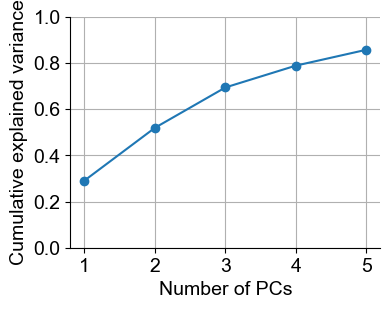

In [7]:
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize = (4, 3))
plt.plot(np.arange(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker = 'o')
plt.ylim((0, 1))
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative explained variance')
plt.grid(True)
plt.show()

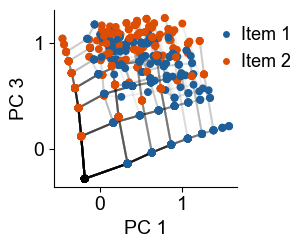

In [8]:
from matplotlib.lines import Line2D

t_plot = 9

colors = ['#dd4d03', '#1f5f99']

plt.figure(figsize = (3.2, 2.7))

for i in range(25000):
    length_ep, values_ep, fixation_seq_ep, hidden_seq_ep, posterior_means_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'hidden_seqs', 'posterior_means_seqs'
    )

    if values_ep[0] == 4 and values_ep[1] == 4 and length_ep > t_plot:

        hidden_seq_pca_ep = pca.transform(hidden_seq_ep)

        colors_ep = [np.array([0.0, 0.0, 0.0, 1.0])]
        for fixation in fixation_seq_ep:
            colors_ep.append(colors[fixation])

        plt.plot(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], color = 'black', alpha = 0.07, zorder = -1)
        sc = plt.scatter(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], c = colors_ep[:t_plot], alpha = 1, s = 22, zorder = 3)

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 3')
legend_elements = [
    Line2D([0], [0], marker = 'o', color = 'w', label = 'Item 1', markerfacecolor = '#1f5f99', markersize = 6),
    Line2D([0], [0], marker = 'o', color = 'w', label = 'Item 2', markerfacecolor = '#dd4d03', markersize = 6)
]
plt.legend(handles = legend_elements, bbox_to_anchor = (0.85, 1), loc = 'upper left', frameon = False, handlelength = 0, fontsize = 13)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_hidden_item.pdf', bbox_inches = 'tight')

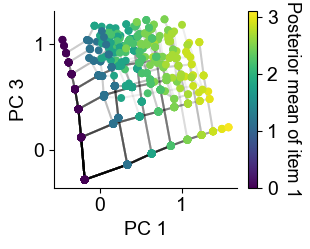

In [11]:
t_plot = 9

plt.figure(figsize = (3.3, 2.7))

for i in range(25000):
    length_ep, values_ep, fixation_seq_ep, hidden_seq_ep, posterior_means_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'hidden_seqs', 'posterior_means_seqs'
    )

    if values_ep[0] == 4 and values_ep[1] == 4 and length_ep > t_plot:

        hidden_seq_pca_ep = pca.transform(hidden_seq_ep)
        
        colors_ep = np.array(posterior_means_seq_ep)[:, 1]
        colors_ep = np.insert(colors_ep, 0, 0)

        plt.plot(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], color = 'black', alpha = 0.07, linewidth = 1.5, zorder = -1)
        sc = plt.scatter(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], c = colors_ep[:t_plot], cmap = 'viridis', vmin = 0, vmax = 3.1, alpha = 1, s = 22, zorder = 3)

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 3')
cbar = plt.colorbar(sc)
cbar.set_label(r'Posterior mean of item 1', rotation = 270, labelpad = 10, va = 'center', fontsize = 13)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_hidden_left.pdf', bbox_inches = 'tight')

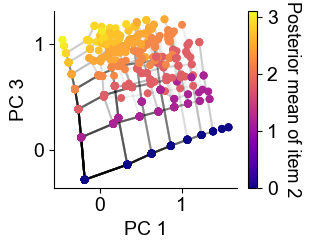

In [12]:
t_plot = 9

plt.figure(figsize = (3.3, 2.7))

for i in range(25000):
    length_ep, values_ep, fixation_seq_ep, hidden_seq_ep, posterior_means_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'hidden_seqs', 'posterior_means_seqs'
    )

    if values_ep[0] == 4 and values_ep[1] == 4 and length_ep > t_plot:

        hidden_seq_pca_ep = pca.transform(hidden_seq_ep)
        
        colors_ep = np.array(posterior_means_seq_ep)[:, 0]
        colors_ep = np.insert(colors_ep, 0, 0)

        plt.plot(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], color = 'black', alpha = 0.07, linewidth = 1.5, zorder = -1)
        sc = plt.scatter(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], c = colors_ep[:t_plot], cmap = 'plasma', vmin = 0, vmax = 3.1, alpha = 1, s = 22, zorder = 3)

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 3')
cbar = plt.colorbar(sc)
cbar.set_label(r'Posterior mean of item 2', rotation = 270, labelpad = 10, va = 'center', fontsize = 13)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_hidden_right.pdf', bbox_inches = 'tight')

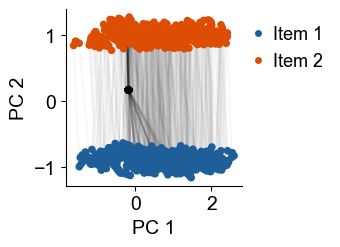

In [14]:
plt.figure(figsize = (3.62, 2.7))

colors = ['#dd4d03', '#1f5f99']

for i in range(500):
    length_ep, values_ep, fixation_seq_ep, hidden_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'hidden_seqs'
    )

    if values_ep[0] > 0 and values_ep[1] > 0:

        hidden_seq_pca_ep = pca.transform(hidden_seq_ep)

        colors_ep = [np.array([0.0, 0.0, 0.0, 1.0])]
        for fixation in fixation_seq_ep:
            colors_ep.append(colors[fixation])

        plt.plot(hidden_seq_pca_ep[:, 0], hidden_seq_pca_ep[:, 1], color = 'black', alpha = 0.03, zorder = 0)
        plt.scatter(hidden_seq_pca_ep[:, 0], hidden_seq_pca_ep[:, 1], c = colors_ep, alpha = 1, s = 20, zorder = 20)

legend_elements = [
    Line2D([0], [0], marker = 'o', color = 'w', label = 'Item 1', markerfacecolor = '#1f5f99', markersize = 6),
    Line2D([0], [0], marker = 'o', color = 'w', label = 'Item 2', markerfacecolor = '#dd4d03', markersize = 6)
]
plt.legend(handles = legend_elements, bbox_to_anchor = (1, 1), loc = 'upper left', frameon = False, handlelength = 0, fontsize = 13)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_hidden_attend.pdf', bbox_inches = 'tight')

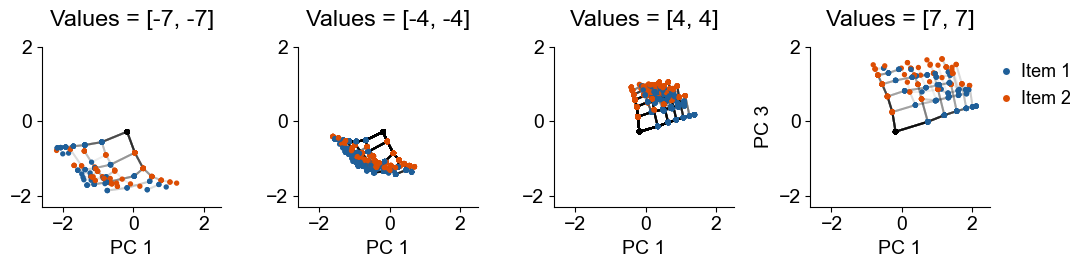

In [81]:
t_plot = 7

pairs = [
    [-7, -7],
    [-4, -4],
    [4, 4],
    [7, 7],
]

colors = ['#dd4d03', '#1f5f99']

plt.figure(figsize = (11.1, 2.9))



for k in range(4):

    plt.subplot(1, 4, k + 1)

    for i in range(num_trials):
        length_ep, values_ep, fixation_seq_ep, hidden_seq_ep, posterior_means_seq_ep = pull(
            data, i, 'lengths', 'values', 'fixation_seqs', 'hidden_seqs', 'posterior_means_seqs'
        )

        if values_ep[0] == pairs[k][0] and values_ep[1] == pairs[k][1] and length_ep > t_plot:

            hidden_seq_pca_ep = pca.transform(hidden_seq_ep)

            colors_ep = [np.array([0.0, 0.0, 0.0, 1.0])]
            for fixation in fixation_seq_ep:
                colors_ep.append(colors[fixation])

            plt.plot(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], color = 'black', alpha = 0.07, zorder = -1)
            sc = plt.scatter(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], c = colors_ep[:t_plot], alpha = 1, s = 8, zorder = 3)

    plt.xlim(-2.6, 2.5)
    plt.ylim(-2.3, 2.0)

    plt.xticks([-2, 0, 2])
    # plt.yticks([0, 1])
    plt.xlabel('PC 1')
    if k == 3:
        plt.ylabel('PC 3')
    plt.title(f'Values = {pairs[k]}', pad = 15)

legend_elements = [
    Line2D([0], [0], marker = 'o', color = 'w', label = 'Item 1', markerfacecolor = '#1f5f99', markersize = 6),
    Line2D([0], [0], marker = 'o', color = 'w', label = 'Item 2', markerfacecolor = '#dd4d03', markersize = 6)
]
plt.legend(handles = legend_elements, bbox_to_anchor = (1, 1), loc = 'upper left', frameon = False, handlelength = 0, fontsize = 13)
plt.tight_layout()
# plt.show()
plt.savefig('figures/p_hidden_item_levels.pdf', bbox_inches = 'tight')

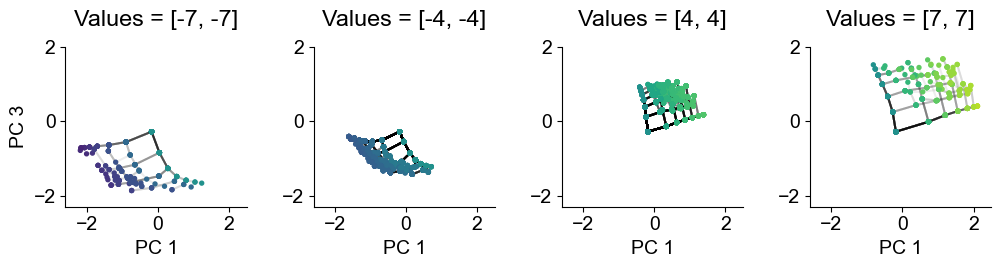

In [ ]:
t_plot = 7

pairs = [
    [-7, -7],
    [-4, -4],
    [4, 4],
    [7, 7],
]

plt.figure(figsize = (10.37, 2.9))



for k in range(4):

    plt.subplot(1, 4, k + 1)

    for i in range(num_trials):
        length_ep, values_ep, fixation_seq_ep, hidden_seq_ep, posterior_means_seq_ep = pull(
            data, i, 'lengths', 'values', 'fixation_seqs', 'hidden_seqs', 'posterior_means_seqs'
        )

        if values_ep[0] == pairs[k][0] and values_ep[1] == pairs[k][1] and length_ep > t_plot:

            hidden_seq_pca_ep = pca.transform(hidden_seq_ep)
            
            colors_ep = np.array(posterior_means_seq_ep)[:, 1]
            colors_ep = np.insert(colors_ep, 0, 0)

            plt.plot(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], color = 'black', alpha = 0.07, linewidth = 1.5, zorder = -1)
            sc = plt.scatter(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], c = colors_ep[:t_plot], cmap = 'viridis', vmin = -6.3, vmax = 6.3, alpha = 1, s = 8, zorder = 3)

    plt.xlim(-2.6, 2.5)
    plt.ylim(-2.3, 2.0)

    plt.xlabel('PC 1')
    if k == 0:
        plt.ylabel('PC 3')
    plt.title(f'Values = {pairs[k]}', pad = 15)

plt.tight_layout()
plt.savefig('figures/p_hidden_left_levels.pdf', bbox_inches = 'tight')

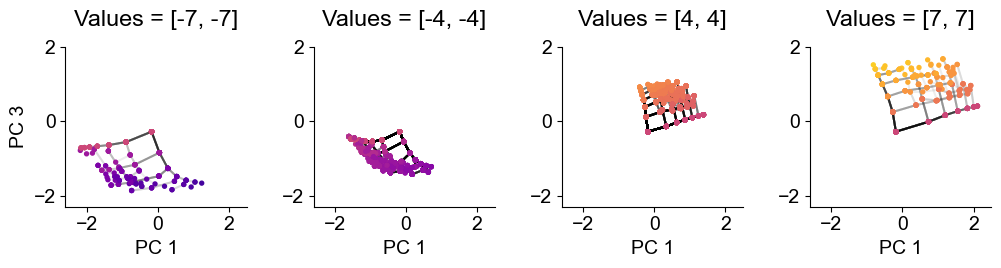

In [ ]:
t_plot = 7

pairs = [
    [-7, -7],
    [-4, -4],
    [4, 4],
    [7, 7],
]

plt.figure(figsize = (10.37, 2.9))



for k in range(4):

    plt.subplot(1, 4, k + 1)

    for i in range(num_trials):
        length_ep, values_ep, fixation_seq_ep, hidden_seq_ep, posterior_means_seq_ep = pull(
            data, i, 'lengths', 'values', 'fixation_seqs', 'hidden_seqs', 'posterior_means_seqs'
        )

        if values_ep[0] == pairs[k][0] and values_ep[1] == pairs[k][1] and length_ep > t_plot:

            hidden_seq_pca_ep = pca.transform(hidden_seq_ep)
            
            colors_ep = np.array(posterior_means_seq_ep)[:, 0]
            colors_ep = np.insert(colors_ep, 0, 0)

            plt.plot(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], color = 'black', alpha = 0.07, linewidth = 1.5, zorder = -1)
            sc = plt.scatter(hidden_seq_pca_ep[:t_plot, 0], hidden_seq_pca_ep[:t_plot, 2], c = colors_ep[:t_plot], cmap = 'plasma', vmin = -6.3, vmax = 6.3, alpha = 1, s = 8, zorder = 3)

    plt.xlim(-2.6, 2.5)
    plt.ylim(-2.3, 2.0)

    plt.xlabel('PC 1')
    if k == 0:
        plt.ylabel('PC 3')
    plt.title(f'Values = {pairs[k]}', pad = 15)

plt.tight_layout()
plt.savefig('figures/p_hidden_right_levels.pdf', bbox_inches = 'tight')